=== EXPERIMENTAL TIE LINES ===


Run 1: Water-rich = [0.9942231121634495, 0.000742187141780654, 0.00503470069476977], EA-rich = [0.03003488855981954, 0.05539725356508779, 0.9145678578750926]
Run 2: Water-rich = [0.9946628917535035, 0.0007990226622513598, 0.004538085584245082], EA-rich = [0.03660237638603146, 0.058484607529399886, 0.9049130160845686]
Run 3: Water-rich = [0.9932602402354824, 0.0009488073363663466, 0.005790952428151247], EA-rich = [0.05953097025249813, 0.060974515216315306, 0.8794945145311867]
Run 4: Water-rich = [0.9924308056598259, 0.0009541998125765252, 0.006614994527597665], EA-rich = [0.0829341423556171, 0.06409555405985083, 0.852970303584532]
Run 5: Water-rich = [0.9917049713223346, 0.0009191478092267033, 0.007375880868438686], EA-rich = [0.11037061275984908, 0.06763537859655726, 0.8219940086435936]
Run 6: Water-rich = [0.9910594723958791, 0.0008898946911864087, 0.00805063291293442], EA-rich = [0.1423814721465989, 0.07155315681548848, 0.7860653710379126]

=== SIMULATED TIE LINES ===


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [5]
└ @ Optim ~/.julia/packages/Optim/7krni/src/multivariate/solvers/constrained/fminbox.jl:441


Run 1: Water-rich = [0.9656140448675825, 0.0036142512744936025, 0.03077170385792388], EA-rich = [0.14776655765637656, 0.04750535567172927, 0.8047280866718942]
Run 2: Water-rich = [0.965661930280462, 0.003810419013178492, 0.03052765070635955], EA-rich = [0.14819993260329667, 0.05002866905412988, 0.8017713983425735]


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [5]
└ @ Optim ~/.julia/packages/Optim/7krni/src/multivariate/solvers/constrained/fminbox.jl:441


...

Run 5: Water-rich = [0.9658103223707717, 0.004550340421144051, 0.02963933720808419], EA-rich = [0.14986241986442703, 0.05947518153301961, 0.7906623986025534]


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [5]
└ @ Optim ~/.julia/packages/Optim/7krni/src/multivariate/solvers/constrained/fminbox.jl:441


Run 6: Water-rich = [0.9658582818154913, 0.0048646836697688505, 0.029277034514739873], EA-rich = [0.15058148277140765, 0.06345212915877615, 0.7859663880698161]


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [5, 6]
└ @ Optim ~/.julia/packages/Optim/7krni/src/multivariate/solvers/constrained/fminbox.jl:441



✓ Ternary diagram saved to 'TernaryDiagram_2_5/ternary_comparison.png'


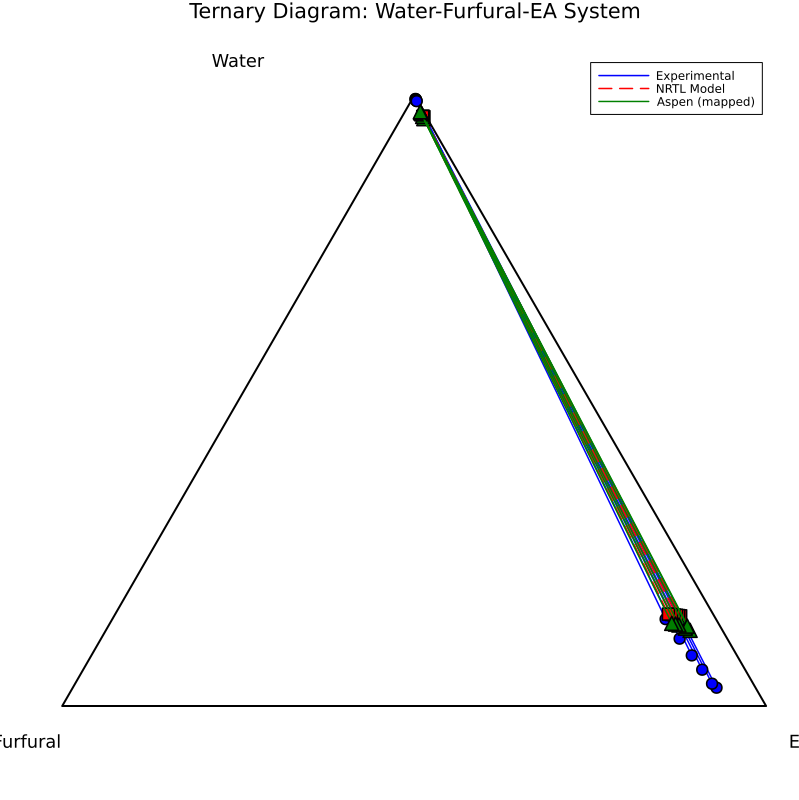


=== COMPARISON SUMMARY ===
Number of experimental tie lines: 6
Number of simulated tie lines: 6

Average water-rich phase error: 0.0363
Average EA-rich phase error: 0.0976
Overall average error: 0.0669


In [3]:
#!/usr/bin/env julia
using CSV, DataFrames, Statistics, LinearAlgebra, Optimization, OptimizationOptimJL, Plots, Zygote
include("../NRTL_Model.jl")  # For activity_coefficients(x, tau)

const MW = [18.01528, 96.084, 88.106]  # H2O, Furfural, EA
function mole_to_mass(x)
    w = x .* MW
    return w ./ sum(w)
end

function mass_to_mole(w)
    x = w ./ MW
    return x ./ sum(x)
end


# --- Pure-component densities (g/mL → g/L) ---
rho_water_gmL, rho_furf_gmL, rho_ea_gmL = 0.997, 1.159, 0.902
rho_water_gL = rho_water_gmL * 1000
rho_furf_gL  = rho_furf_gmL  * 1000
rho_ea_gL    = rho_ea_gmL    * 1000

# --- Load data ---
prep_file = "pre-processed in data.csv"
exp_compositions_file = "ternary_compositions.csv"  # CSV from previous script

prep_df = CSV.read(prep_file, DataFrame)
exp_df = CSV.read(exp_compositions_file, DataFrame)

# --- Load Aspen-mapped tie lines (mass-basis) ---
aspen_mapped_file = "mapped_tielines_aspen_massbasis.csv"  # <- your file
aspen_map_df = CSV.read(aspen_mapped_file, DataFrame)

# --- Load fitted tau matrix ---
τ_file = "../fitted_tau_matrix_2_5.csv"
τ_fitted = CSV.read(τ_file, DataFrame) |> Matrix{Float64}

# --- LLE solver ---
function solve_lle(z, tau)
    n = length(z)
    z_norm = z ./ sum(z)
    best_x_global, best_y_global = nothing, nothing
    best_loss_global = Inf

    # Diverse initial strategies
    initial_strategies = [
        (z_norm .+ 0.2, z_norm .- 0.2),
        (z_norm .* 0.1, z_norm .* 1.9),
        ([0.8,0.1,0.1],[0.1,0.1,0.8]),
        ([0.1,0.1,0.8],[0.8,0.1,0.1]),
        ([0.98,0.01,0.01],[0.01,0.01,0.98])
    ]

    # Objective function
    lle_obj(x_guess) = begin
        x = @view x_guess[1:n]
        y = @view x_guess[n+1:end]
        x_norm = x ./ sum(x)
        y_norm = y ./ sum(y)
        gamma_x = activity_coefficients(x_norm, tau)
        gamma_y = activity_coefficients(y_norm, tau)
        log_ax = log.(x_norm .* gamma_x .+ 1e-12)
        log_ay = log.(y_norm .* gamma_y .+ 1e-12)
        phase_eq_error = sum((log_ax .- log_ay).^2)
        diff_xy = x_norm .- y_norm
        denom = sum(diff_xy .* diff_xy) + 1e-12
        β = sum((z_norm .- y_norm) .* diff_xy) / denom
        z_calc = β .* x_norm .+ (1 - β) .* y_norm
        mass_balance_error = 10.0 * sum((z_norm .- z_calc).^2)
        beta_penalty = 100.0*(max(0.0,-β)^2 + max(0.0,β-1.0)^2)
        trivial_penalty = 1000.0*exp(-50.0*sum((x_norm .- y_norm).^2))
        return phase_eq_error + mass_balance_error + beta_penalty + trivial_penalty
    end

    for (x_init,y_init) in initial_strategies
        x0 = vcat(clamp.(x_init,1e-6,1-1e-6), clamp.(y_init,1e-6,1-1e-6))
        prob = OptimizationProblem(OptimizationFunction((x,p)->lle_obj(x), Optimization.AutoZygote()), x0,
                                   nothing, lb=fill(1e-6,2n), ub=fill(1.0,2n))
        sol = solve(prob, OptimizationOptimJL.LBFGS(), maxiters=300, reltol=1e-8)
        if sol.retcode == ReturnCode.Success || sol.retcode == ReturnCode.MaxIters
            final_loss = lle_obj(sol.u)
            if final_loss < best_loss_global
                best_loss_global = final_loss
                best_x_global = sol.u[1:n]
                best_y_global = sol.u[n+1:end]
            end
        end
    end

    if best_x_global === nothing
        error("Solver failed to find a solution")
    end

    x_eq = best_x_global ./ sum(best_x_global)
    y_eq = best_y_global ./ sum(best_y_global)

    # Return phases (Water-rich first)
    if x_eq[1] > y_eq[1]
        return x_eq, y_eq
    else
        return y_eq, x_eq
    end
end

# --- Helper function for ternary plotting ---
function ternary_to_cartesian(w, f, ea)
    # Standard ternary coordinates
    # Top vertex: Water (0, 1)
    # Bottom-left: Furfural (0, 0)
    # Bottom-right: EA (sqrt(3)/2, 0)
    x = 0.5 * (2 * ea + w) / (f + w + ea)
    y = (sqrt(3) / 2) * w / (f + w + ea)
    return x, y
end

# --- Extract experimental tie lines from CSV ---
println("=== EXPERIMENTAL TIE LINES ===")
exp_tie_lines = []
for i in 1:nrow(exp_df)
    water_rich = mass_to_mole([exp_df[i, :Water_rich_W], exp_df[i, :Water_rich_F], exp_df[i, :Water_rich_EA]])
    ea_rich = mass_to_mole([exp_df[i, :EA_rich_W], exp_df[i, :EA_rich_F], exp_df[i, :EA_rich_EA]])
    push!(exp_tie_lines, (water_rich, ea_rich))
    println("Run $(exp_df[i, :Run]): Water-rich = $water_rich, EA-rich = $ea_rich")
end

# --- Generate simulated tie lines using same feeds ---
println("\n=== SIMULATED TIE LINES ===")
sim_tie_lines = []
for i in 1:nrow(prep_df)
    # Feed composition (mass fractions)
    M_H2O = prep_df[i, Symbol("Amount Water (g)")]
    M_FUR = prep_df[i, Symbol("Amount Furfural (g)")]
    M_EA = prep_df[i, Symbol("Amount Ethyl Acetate (g)")]
    
    z_feed = [M_H2O, M_FUR, M_EA]
    z_feed_mass = z_feed ./ sum(z_feed)
    z_feed_frac = mass_to_mole(z_feed_mass) # pass it in mole!
    
    # Solve LLE
    phase1, phase2 = solve_lle(z_feed_frac, τ_fitted)
    
    push!(sim_tie_lines, (phase1, phase2))
    println("Run $i: Water-rich = $phase1, EA-rich = $phase2")
end

# --- Create ternary diagram ---
gr()  # Use GR backend

# Set up plot
p = plot(
    aspect_ratio=:equal,
    legend=:topright,
    size=(800, 800),
    title="Ternary Diagram: Water-Furfural-EA System",
    xlabel="",
    ylabel="",
    grid=false,
    showaxis=false
)

# Draw triangle
triangle_x = [0, 1, 0.5, 0]
triangle_y = [0, 0, sqrt(3)/2, 0]
plot!(p, triangle_x, triangle_y, color=:black, linewidth=2, label="")

# Add vertex labels
annotate!(p, 0.25, sqrt(3)/2 + 0.05, text("Water", :center, 12))
annotate!(p, -0.05, -0.05, text("Furfural", :center, 12))
annotate!(p, 1.05, -0.05, text("EA", :center, 12))

# Plot experimental tie lines
for (i, (water_rich, ea_rich)) in enumerate(exp_tie_lines)
    x1, y1 = ternary_to_cartesian(water_rich[1], water_rich[2], water_rich[3])
    x2, y2 = ternary_to_cartesian(ea_rich[1], ea_rich[2], ea_rich[3])
    
    # Plot tie line
    plot!(p, [x1, x2], [y1, y2], 
          color=:blue, linestyle=:solid, linewidth=1.5, 
          label=(i==1 ? "Experimental" : ""))
    
    # Plot points
    scatter!(p, [x1], [y1], color=:blue, markersize=6, label="")
    scatter!(p, [x2], [y2], color=:blue, markersize=6, label="")
end

# Plot simulated tie lines
for (i, (phase1, phase2)) in enumerate(sim_tie_lines)
    x1, y1 = ternary_to_cartesian(phase1[1], phase1[2], phase1[3]) # plot is in moles
    x2, y2 = ternary_to_cartesian(phase2[1], phase2[2], phase2[3])
    
    # Plot tie line
    plot!(p, [x1, x2], [y1, y2], 
          color=:red, linestyle=:dash, linewidth=1.5, 
          label=(i==1 ? "NRTL Model" : ""))
    
    # Plot points
    scatter!(p, [x1], [y1], color=:red, marker=:square, markersize=6, label="")
    scatter!(p, [x2], [y2], color=:red, marker=:square, markersize=6, label="")
end

# Plot Aspen-mapped tie lines (mass → mole; green triangles)
for i in 1:nrow(aspen_map_df)
    # Mass fractions from the mapped file
    wr_mass = [aspen_map_df[i, :WR_W], aspen_map_df[i, :WR_F], aspen_map_df[i, :WR_EA]]
    ea_mass = [aspen_map_df[i, :EA_W], aspen_map_df[i, :EA_F], aspen_map_df[i, :EA_EA]]

    # Convert to mole fractions to match plotting basis
    wr_mole = mass_to_mole(wr_mass)
    ea_mole = mass_to_mole(ea_mass)

    # Ternary → Cartesian
    x1, y1 = ternary_to_cartesian(wr_mole[1], wr_mole[2], wr_mole[3])
    x2, y2 = ternary_to_cartesian(ea_mole[1], ea_mole[2], ea_mole[3])

    # Tie line
    plot!(p, [x1, x2], [y1, y2],
          color=:green, linestyle=:solid, linewidth=1.5,
          label=(i==1 ? "Aspen (mapped)" : ""))

    # Endpoints (green triangles)
    scatter!(p, [x1], [y1], color=:green, marker=:utriangle, markersize=7, label="")
    scatter!(p, [x2], [y2], color=:green, marker=:utriangle, markersize=7, label="")
end

# Save plot
output_dir = "TernaryDiagram_2_5"
mkpath(output_dir)
savefig(p, joinpath(output_dir, "ternary_comparison.png"))
println("\n✓ Ternary diagram saved to '$(output_dir)/ternary_comparison.png'")

display(p)

# --- Summary statistics ---
println("\n=== COMPARISON SUMMARY ===")
println("Number of experimental tie lines: ", length(exp_tie_lines))
println("Number of simulated tie lines: ", length(sim_tie_lines))

# Calculate average errors
water_phase_errors = []
ea_phase_errors = []

for i in 1:min(length(exp_tie_lines), length(sim_tie_lines))
    exp_w, exp_e = exp_tie_lines[i]
    sim_w, sim_e = sim_tie_lines[i]
    
    # Euclidean distance in composition space
    err_w = sqrt(sum((exp_w .- sim_w).^2))
    err_e = sqrt(sum((exp_e .- sim_e).^2))
    
    push!(water_phase_errors, err_w)
    push!(ea_phase_errors, err_e)
end

println("\nAverage water-rich phase error: ", round(mean(water_phase_errors), digits=4))
println("Average EA-rich phase error: ", round(mean(ea_phase_errors), digits=4))
println("Overall average error: ", round(mean([water_phase_errors; ea_phase_errors]), digits=4))

In [8]:
using StatsPlots, DataFrames, Statistics, Colors, Printf, Random


default(fontfamily="Helvetica", linewidth=1.4, grid=false, framestyle=:box)

p = plot(
    ylabel="Furfural mole fraction",
    xlabel="Phase",
    title="Furfural Distribution in Water-rich and EA-rich Phases",
    legend=:topright,
    size=(850, 600),
    framestyle=:box
)

# Build furfural_df and stats from tie-lines
phases = String[]
sources = String[]
furf = Float64[]
for (w,e) in exp_tie_lines
    push!(phases, "Water-rich"); push!(sources, "Experimental"); push!(furf, w[2])
    push!(phases, "EA-rich");    push!(sources, "Experimental"); push!(furf, e[2])
end
for (w,e) in sim_tie_lines
    push!(phases, "Water-rich"); push!(sources, "Model"); push!(furf, w[2])
    push!(phases, "EA-rich");    push!(sources, "Model"); push!(furf, e[2])
end
furfural_df = DataFrame(Phase=phases, Source=sources, Furfural=furf)
stats = combine(groupby(furfural_df, [:Phase, :Source]),
                :Furfural => mean => :Mean,
                :Furfural => std => :SD,
                :Furfural => x -> length(x) => :N)

# Separate data
water_data = furfural_df[furfural_df.Phase .== "Water-rich", :]
ea_data    = furfural_df[furfural_df.Phase .== "EA-rich", :]

# --- Boxplots (same as before) ---
boxplot!([fill("Water-rich (Exp)", nrow(water_data[water_data.Source .== "Experimental", :]))],
         water_data[water_data.Source .== "Experimental", :Furfural],
         color=RGB(0.25,0.45,0.9), fillalpha=0.55, label="Experimental")

boxplot!([fill("Water-rich (Mod)", nrow(water_data[water_data.Source .== "Model", :]))],
         water_data[water_data.Source .== "Model", :Furfural],
         color=RGB(0.9,0.35,0.3), fillalpha=0.55, label="Model")

boxplot!([fill("EA-rich (Exp)", nrow(ea_data[ea_data.Source .== "Experimental", :]))],
         ea_data[ea_data.Source .== "Experimental", :Furfural],
         color=RGB(0.25,0.45,0.9), fillalpha=0.55, label="")

boxplot!([fill("EA-rich (Mod)", nrow(ea_data[ea_data.Source .== "Model", :]))],
         ea_data[ea_data.Source .== "Model", :Furfural],
         color=RGB(0.9,0.35,0.3), fillalpha=0.55, label="")

# --- “Swarm” overlay using scatter! + random jitter ---
Random.seed!(1234)
x_positions = ["Water-rich (Exp)", "Water-rich (Mod)", "EA-rich (Exp)", "EA-rich (Mod)"]

function jittered_swarm!(x_label, y_values)
    xvals = fill(x_label, length(y_values))
    # add tiny horizontal jitter so points spread visually
    scatter!(xvals, y_values, marker=:circle, ms=3, alpha=0.7, color=:black, jitter=0.15, label="")
end

jittered_swarm!("Water-rich (Exp)", water_data[water_data.Source .== "Experimental", :Furfural])
jittered_swarm!("Water-rich (Mod)", water_data[water_data.Source .== "Model", :Furfural])
jittered_swarm!("EA-rich (Exp)", ea_data[ea_data.Source .== "Experimental", :Furfural])
jittered_swarm!("EA-rich (Mod)", ea_data[ea_data.Source .== "Model", :Furfural])

# --- Mean ± SD labels (3 decimals) ---
x_map = Dict(
    ("Water-rich", "Experimental") => "Water-rich (Exp)",
    ("Water-rich", "Model") => "Water-rich (Mod)",
    ("EA-rich", "Experimental") => "EA-rich (Exp)",
    ("EA-rich", "Model") => "EA-rich (Mod)"
)

for row in eachrow(stats)
    xpos = x_map[(row.Phase, row.Source)]
    yval = row.Mean
    scatter!([xpos], [yval], color=:black, marker=:diamond, ms=5, label=false)
    annotate!(xpos, yval + maximum(furfural_df.Furfural)*0.02,
            text(@sprintf("%.3f ± %.3f", row.Mean, row.SD), :black, 8, :center))
end

# === Save ===
mkpath("TernaryDiagram_2_5")
savefig(p, "TernaryDiagram_2_5/furfural_box_swarm_comparison.pdf")
savefig(p, "TernaryDiagram_2_5/furfural_box_swarm_comparison.png")
println("\n✓ Saved to 'TernaryDiagram_2_5/furfural_box_swarm_comparison.[pdf|png]'")




✓ Saved to 'TernaryDiagram_2_5/furfural_box_swarm_comparison.[pdf|png]'



✓ Ternary diagram saved to 'TernaryDiagram_2_5/ternary_comparison_no_aspen.png'


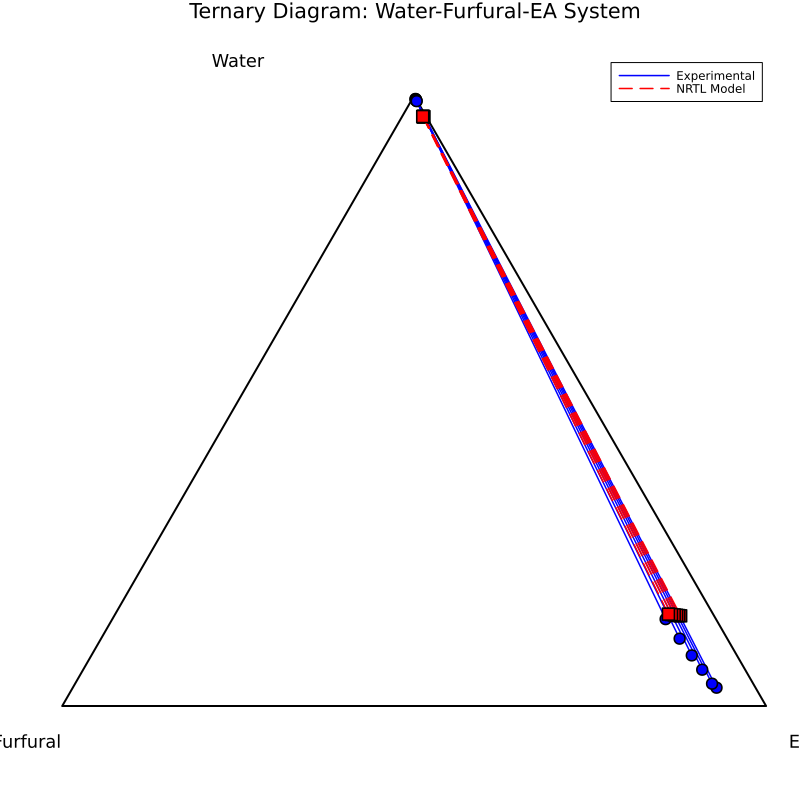


=== COMPARISON SUMMARY ===
Number of experimental tie lines: 6
Number of simulated tie lines: 6

Average water-rich phase error: 0.0363
Average EA-rich phase error: 0.0976
Overall average error: 0.0669


In [9]:

# --- Create ternary diagram ---
gr()  # Use GR backend

# Set up plot
p2 = plot(
    aspect_ratio=:equal,
    legend=:topright,
    size=(800, 800),
    title="Ternary Diagram: Water-Furfural-EA System",
    xlabel="",
    ylabel="",
    grid=false,
    showaxis=false
)

# Draw triangle
triangle_x = [0, 1, 0.5, 0]
triangle_y = [0, 0, sqrt(3)/2, 0]
plot!(p2, triangle_x, triangle_y, color=:black, linewidth=2, label="")

# Add vertex labels
annotate!(p2, 0.25, sqrt(3)/2 + 0.05, text("Water", :center, 12))
annotate!(p2, -0.05, -0.05, text("Furfural", :center, 12))
annotate!(p2, 1.05, -0.05, text("EA", :center, 12))

# Plot experimental tie lines
for (i, (water_rich, ea_rich)) in enumerate(exp_tie_lines)
    x1, y1 = ternary_to_cartesian(water_rich[1], water_rich[2], water_rich[3])
    x2, y2 = ternary_to_cartesian(ea_rich[1], ea_rich[2], ea_rich[3])
    
    # Plot tie line
    plot!(p2, [x1, x2], [y1, y2], 
          color=:blue, linestyle=:solid, linewidth=1.5, 
          label=(i==1 ? "Experimental" : ""))
    
    # Plot points
    scatter!(p2, [x1], [y1], color=:blue, markersize=6, label="")
    scatter!(p2, [x2], [y2], color=:blue, markersize=6, label="")
end

# Plot simulated tie lines
for (i, (phase1, phase2)) in enumerate(sim_tie_lines)
    x1, y1 = ternary_to_cartesian(phase1[1], phase1[2], phase1[3]) # plot is in moles
    x2, y2 = ternary_to_cartesian(phase2[1], phase2[2], phase2[3])
    
    # Plot tie line
    plot!(p2, [x1, x2], [y1, y2], 
          color=:red, linestyle=:dash, linewidth=1.5, 
          label=(i==1 ? "NRTL Model" : ""))
    
    # Plot points
    scatter!(p2, [x1], [y1], color=:red, marker=:square, markersize=6, label="")
    scatter!(p2, [x2], [y2], color=:red, marker=:square, markersize=6, label="")
end

# Save plot
output_dir = "TernaryDiagram_2_5"
mkpath(output_dir)
savefig(p2, joinpath(output_dir, "ternary_comparison_no_aspen.png"))
println("\n✓ Ternary diagram saved to '$(output_dir)/ternary_comparison_no_aspen.png'")

display(p2)

# --- Summary statistics ---
println("\n=== COMPARISON SUMMARY ===")
println("Number of experimental tie lines: ", length(exp_tie_lines))
println("Number of simulated tie lines: ", length(sim_tie_lines))

# Calculate average errors
water_phase_errors = []
ea_phase_errors = []

for i in 1:min(length(exp_tie_lines), length(sim_tie_lines))
    exp_w, exp_e = exp_tie_lines[i]
    sim_w, sim_e = sim_tie_lines[i]
    
    # Euclidean distance in composition space
    err_w = sqrt(sum((exp_w .- sim_w).^2))
    err_e = sqrt(sum((exp_e .- sim_e).^2))
    
    push!(water_phase_errors, err_w)
    push!(ea_phase_errors, err_e)
end

println("\nAverage water-rich phase error: ", round(mean(water_phase_errors), digits=4))
println("Average EA-rich phase error: ", round(mean(ea_phase_errors), digits=4))
println("Overall average error: ", round(mean([water_phase_errors; ea_phase_errors]), digits=4))

In [10]:
using StatsPlots, Statistics, Printf

# === Data ===
exp_water = [tie[1][2] for tie in exp_tie_lines]
exp_ea    = [tie[2][2] for tie in exp_tie_lines]
mod_water = [tie[1][2] for tie in sim_tie_lines]
mod_ea    = [tie[2][2] for tie in sim_tie_lines]

Exp   = vcat(exp_water, exp_ea)
Mod   = vcat(mod_water, mod_ea)
Phase = vcat(fill("Water-rich", length(exp_water)),
             fill("EA-rich",    length(exp_ea)))

# === Regression ===
A = hcat(ones(length(Exp)), Exp)
a, b = A \ Mod
r2   = cor(Exp, Mod)^2
rmse = sqrt(mean((Mod .- (a .+ b .* Exp)).^2))

# === Axes limits ===
lims = (0.0, max(maximum(Exp), maximum(Mod)) * 1.05)
xfit = collect(range(lims[1], lims[2], length=200))
yfit = a .+ b .* xfit

# === Plot ===
default(fontfamily="Helvetica", linewidth=1.4, framestyle=:box)

p = plot(; xlabel="Experimental mole fraction",
          ylabel="Model-predicted mole fraction",
          title="Parity Plot: Furfural Mole Fraction per Phase",
          size=(750, 600),
          legend=:topleft,
          xlim=lims, ylim=lims)

# Explicit scatter calls with vector wrapping
wr_mask = Phase .== "Water-rich"
ea_mask = .!wr_mask

scatter!(Exp[wr_mask], Mod[wr_mask];
         color=RGB(0.25,0.45,0.9), markersize=6, alpha=0.9, label="Water-rich")
scatter!(Exp[ea_mask], Mod[ea_mask];
         color=RGB(0.9,0.35,0.3),  markersize=6, alpha=0.9, label="EA-rich")

# Add 1:1 and fit lines (vectors always!)
plot!(collect(lims), collect(lims);
      color=:black, linestyle=:dash, label="1:1 line")
plot!(xfit, yfit;
      color=:gray, linewidth=2, label="Linear fit")

# === Annotation (text only, no polygons) ===
x_anno = lims[1] + 0.65*(lims[2]-lims[1])
y_anno = lims[1] + 0.15*(lims[2]-lims[1])

annotate!([x_anno], [y_anno],
          text(@sprintf("Fit: y = %.3f + %.3f x\nR² = %.3f   RMSE = %.4f",
                        a, b, r2, rmse),
               :black, 9, :left))

# === Save ===
println(@sprintf("✓ Parity plot saved. R²=%.3f, RMSE=%.4f, slope=%.3f, intercept=%.3f",
                 r2, rmse, b, a))






✓ Parity plot saved. R²=0.785, RMSE=0.0109, slope=0.668, intercept=0.004


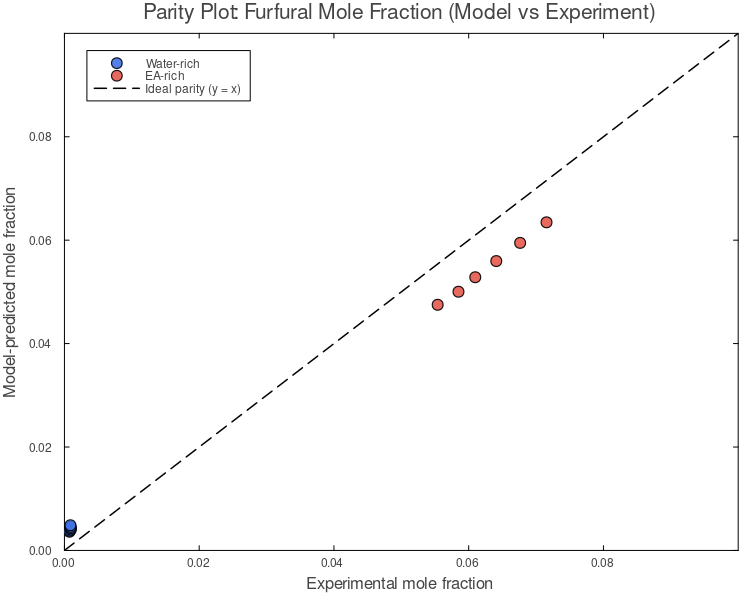


───────────────────────────────────────────────────────────────
Phase         |   RMSE       MAE        Bias       CCC
───────────────────────────────────────────────────────────────
Water-rich    |  0.00334   0.00331   +0.00331   0.004
EA-rich       |  0.00815   0.00815   -0.00815   0.517
───────────────────────────────────────────────────────────────
Overall       |  0.00623   0.00573   -0.00242   0.977
───────────────────────────────────────────────────────────────
✓ Saved to 'TernaryDiagram_2_5/furfural_parity_clean.[pdf|png]'


In [10]:
using StatsPlots, Statistics, Printf, Colors

# === Data extraction ===
exp_water = [tie[1][2] for tie in exp_tie_lines]
exp_ea    = [tie[2][2] for tie in exp_tie_lines]
mod_water = [tie[1][2] for tie in sim_tie_lines]
mod_ea    = [tie[2][2] for tie in sim_tie_lines]

# === Agreement metrics (no R²) ===
function agreement_metrics(exp::Vector{<:Real}, mod::Vector{<:Real})
    diff = mod .- exp
    rmse = sqrt(mean(diff.^2))
    mae  = mean(abs.(diff))
    bias = mean(diff)
    μx, μy = mean(exp), mean(mod)
    σx2, σy2 = var(exp), var(mod)
    ρ = cor(exp, mod)
    ccc = (2 * ρ * sqrt(σx2) * sqrt(σy2)) / (σx2 + σy2 + (μx - μy)^2)
    return (rmse=rmse, mae=mae, bias=bias, ccc=ccc)
end

stats_w = agreement_metrics(exp_water, mod_water)
stats_e = agreement_metrics(exp_ea, mod_ea)
stats_all = agreement_metrics(vcat(exp_water, exp_ea), vcat(mod_water, mod_ea))

# === Axis limits ===
lims = (0.0, max(maximum(vcat(exp_water, exp_ea, mod_water, mod_ea)), 0.1))

# === Plot ===
default(fontfamily="Helvetica", linewidth=1.4, grid=false, framestyle=:box)

p = plot(
    xlabel="Experimental mole fraction",
    ylabel="Model-predicted mole fraction",
    title="Parity Plot: Furfural Mole Fraction (Model vs Experiment)",
    legend=:topleft,
    size=(750, 600),
    xlim=lims, ylim=lims
)

# Scatter points per phase
scatter!(exp_water, mod_water;
         color=RGB(0.25,0.45,0.9), markersize=6, alpha=0.9, label="Water-rich")
scatter!(exp_ea, mod_ea;
         color=RGB(0.9,0.35,0.3), markersize=6, alpha=0.9, label="EA-rich")

# 1:1 parity line
plot!(collect(lims), collect(lims);
      color=:black, linestyle=:dash, linewidth=1.5, label="Ideal parity (y = x)")

# === Save ===
mkpath("TernaryDiagram_2_5")
savefig(p, "TernaryDiagram_2_5/furfural_parity_plot.pdf")
savefig(p, "TernaryDiagram_2_5/furfural_parity_plot.png")
display(p)

# === Print formatted stats below ===
println("\n───────────────────────────────────────────────────────────────")
println("Phase         |   RMSE       MAE        Bias       CCC")
println("───────────────────────────────────────────────────────────────")
@printf("Water-rich    |  %.5f   %.5f   %+0.5f   %.3f\n",
        stats_w.rmse, stats_w.mae, stats_w.bias, stats_w.ccc)
@printf("EA-rich       |  %.5f   %.5f   %+0.5f   %.3f\n",
        stats_e.rmse, stats_e.mae, stats_e.bias, stats_e.ccc)
println("───────────────────────────────────────────────────────────────")
@printf("Overall       |  %.5f   %.5f   %+0.5f   %.3f\n",
        stats_all.rmse, stats_all.mae, stats_all.bias, stats_all.ccc)
println("───────────────────────────────────────────────────────────────")
println("✓ Saved to 'TernaryDiagram_2_5/furfural_parity_clean.[pdf|png]'")
